(sec:agent)=
# Agent-based modeling

An [agent based model](https://en.wikipedia.org/wiki/Agent-based_model) (ABM) is a computational model for simulating the actions and interactions of autonomous agents (both individual or collective entities such as organizations or groups) in order to understand the behavior of a system and what governs its outcomes.

Every ABM requires two classes, one for the overall model and one for the agents. These classes will be derived classes of Mesa's base classes `Model` and `Agent`. The model class holds the model-level attributes, manages the agents, and generally handles the global level of our model. Each instantiation of the model class will be a specific model run. Each model will contain multiple agents, all of which are instantiations of the agent class.

In [1]:
import mesa

## Defining the model

- $N$ agents are randomly walking around in a 2D landscape grid of cells
- To begin with, the agents are randomly positioned and has one unit of wealth
- If an agent has nonzero wealth and enters into a non-empty cell, the agent will give one unit of wealth to a random cellmate
- Focus is set on wealth distribution over time

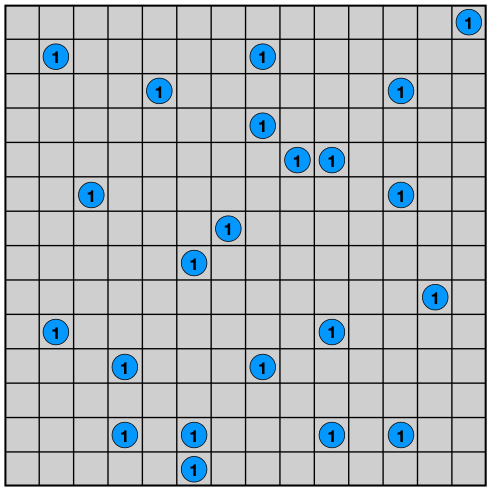

## Implmenting the model

### CellAgent

Every agent starts with a wealth of 1. If an agent has nonzero wealth and enters into a non-empty cell, the agent will give one unit of wealth to a random cellmate.

In [2]:
class MoneyAgent(mesa.discrete_space.CellAgent):

    def __init__(self, model, cell):
        super().__init__(model)

        self.move_to(cell)  # place agent in grid

        self.wealth = 1

    def move(self):

        new_cell = self.cell.neighborhood.select_random_cell()
        self.move_to(new_cell)

        cellmates = [a for a in self.cell.agents if a is not self]

        if self.wealth > 0 and len(cellmates) > 0:
            other_agent = self.random.choice(cellmates)
            other_agent.wealth += 1
            self.wealth -= 1

### Model
Create a model that defines a data collector that in each time step records the wealth of agents and the overall indicator for wealth distribution.

In [3]:
class MoneyModel(mesa.Model):

    def __init__(self, number_agents, width, height):
        super().__init__()  # parent class initialization

        self.grid = mesa.discrete_space.OrthogonalMooreGrid(
            (width, height), torus=False, random=self.random
        )

        MoneyAgent.create_agents(
            self,
            number_agents,
            # Randomly select cells for agents
            self.random.choices(self.grid.all_cells.cells, k=number_agents),
        )

        self.datacollector = mesa.DataCollector(
            model_reporters={"Gini coefficient": lambda m: m.compute_gini()},
            agent_reporters={
                "Wealth": "wealth",
                "Agent position": lambda a: a.cell.position,
            },
        )

    def compute_gini(self):

        N = len(self.agents)

        # collect wealth of agents into a list and sort it in increasing order
        agent_wealths = [agent.wealth for agent in self.agents]

        x = sorted(agent_wealths)
        X = sum(x)

        if X == 0:
            return 0

        # calculate the Gini coefficient
        B = sum(xi * (N + 1 - i) for i, xi in enumerate(x, start=1))
        G = (N + 1 - 2 * B / X) / N

        return G

    def step(self):
        self.datacollector.collect(self)
        self.agents.shuffle_do("move")

#### Reporter

As metric indicator of wealth distribution, we have here implemented the [Gini coefficient](https://en.wikipedia.org/wiki/Gini_coefficient). Let $x_i$ for $i = 1,\ldots, N$ be the wealth of $N$ individuals ordered such that $x_i \leq x_{i+1}$. The Gini coefficient for this population is

$$
G = \frac{1}{N}
\Big(
N + 1 - \frac{2}{X} \sum_{i=1}^N (N+1-i) x_i
\Big)
$$

where $X$ is the sum of wealths, or, in other words, the total population wealth. There are two limting values for $G$. If every individual has the same wealth, then $G = 0$. If the total population wealth belongs to a single individual, then $G = (1 - 1/N)$.

## Running the simulation

Let us run a model with 10,000 agents distributed in a 1,000 $\times$ 1,000 grid of cells for 2,000 time steps.

In [4]:
model = MoneyModel(10000, 1000, 1000)

In [5]:
model.run_for(2000)

## Analyzing the simulation

### Collecting stored data

After the simulation, we collect the model and agent data that are stored using the [Pandas](https://pandas.pydata.org/docs/getting_started/overview.html) `DataFrame` data structure.

In [6]:
model_df = model.datacollector.get_model_vars_dataframe()
agent_df = model.datacollector.get_agent_vars_dataframe()

We expose the data structures with use of the methods `head(n)` and `tail(n)` showing, respectively, the first and last *n* rows of the dataframes.

In [7]:
model_df.head(5)

,Gini coefficient
0,0.000000
1,0.016856
2,0.034584
3,0.045519
4,0.057077


In [8]:
agent_df.tail(5)

Wealth  Agent position
Step   AgentID                        
2000.0 9996          2  [727.0, 257.0]
       9997          1   [45.0, 394.0]
       9998          6  [197.0, 255.0]
       9999          0   [72.0, 608.0]
       10000         0   [970.0, 83.0]

### Plotting results

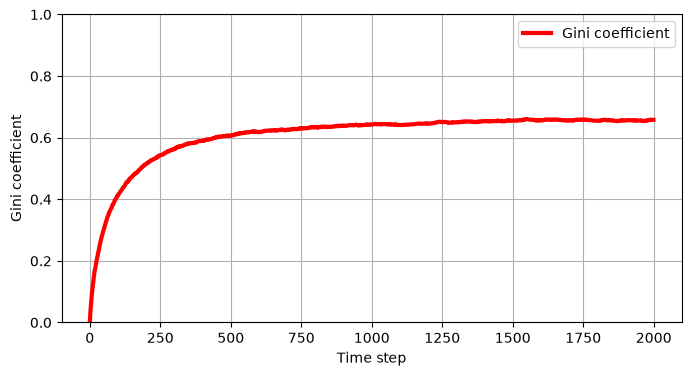

In [9]:
import matplotlib.pyplot as plt

model_df.plot(color="r", lw=3, figsize=(8, 4))

plt.ylabel("Gini coefficient")
plt.xlabel("Time step")
plt.grid("on")
plt.setp(plt.gca(), ylim=(0, 1))

plt.show()

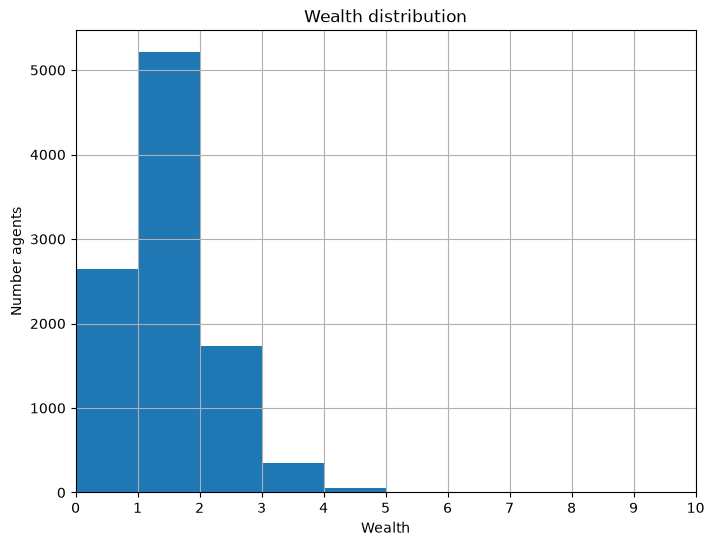

In [10]:
# extract a cross section of the dataframe for the final time step
final_wealth_df = agent_df.xs(99, level="Step")

final_wealth_df.hist(bins=range(11), figsize=(8, 6))

plt.title("Wealth distribution")
plt.ylabel("Number agents")
plt.xlabel("Wealth")
plt.setp(plt.gca(), xlim=(0, 10), xticks=range(11))

plt.show()

Let us find the agent that accumulated maximum wealth and the time step at which this occured.

In [11]:
step_idx, agent_idx = agent_df["Wealth"].idxmax()

print("Agent:", agent_idx)
print("Step:", step_idx)

Agent: 9683
Step: 1865.0


Let us plot the time series of wealth for this agent.

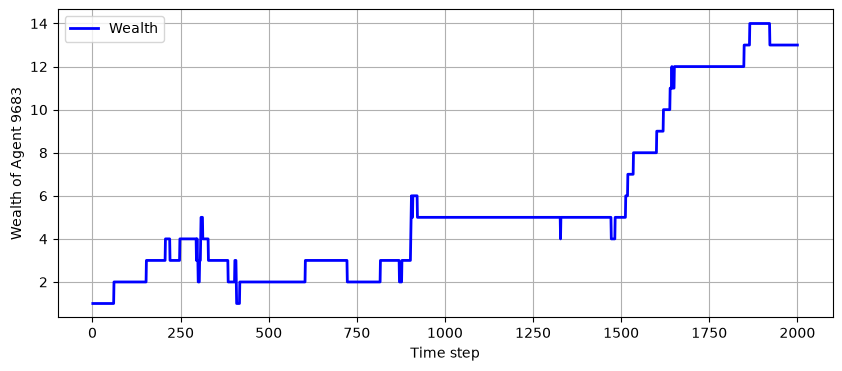

In [12]:
one_agent_wealth_df = agent_df.xs(agent_idx, level="AgentID")

one_agent_wealth_df.plot(lw=2, color="b", figsize=(10, 4))

plt.ylabel(f"Wealth of Agent {agent_idx}")
plt.xlabel("Time step")

plt.grid(True)

plt.show()